# Dataloader

In [1]:
from src.dataloading.gnndataloader import GNNDataLoader
from src.utils import get_data_env

modelname   = 'temporal_gcn__'
gg          = 'commuter_t1000_selfmean_rowwise'
name        = modelname + f"{gg}"

disease_name    = 'influenza'
model           = 'tgcn'
nuts_level      = 'nuts3'
min_date        ='2006-05-15'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False


horizon_size    = 1
horizon_leadtime= 3
sequence_length = 12
lags            = 1


# training hparams
n_epochs        = 100
lr              = 0.0005
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :   {'mode': 'min', 'factor': 0.5, 'patience': 7},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

epidata_loader_basis = GNNDataLoader(disease_name, get_data_env(), nuts_level=nuts_level, min_date=min_date,max_date=max_date, include_population=False, horizon_size = horizon_size, horizon_leadtime = horizon_leadtime, sequence_length=sequence_length, split_berlin=split_berlin)
epidata_loader_basis.add_time_features()
epidata_loader_basis.log_transform_target()
epidata_loader_basis.set_splits(split_trainval, split_valtest)
epidata_loader_basis.normalize()
epidata_loader_basis.add_lagged_features(lags = lags)
epidata_loader_basis.finalize()
dl = epidata_loader_basis.retrieve_graph(gg).construct_dataloaders()

Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-01-30 (+15 weeks)
berlin districts removed


# DeepModel

In [15]:
import torch
import torch.nn as nn
from typing import Dict, Optional, Callable, Any, List
from abc import ABC, abstractmethod

class BaseLoss(nn.Module, ABC):
    """
    Abstract base class for all loss functions.
    
    Ensures consistency across loss implementations and provides
    common utilities like device management and validation.
    """
    
    def __init__(self, **kwargs):
        super().__init__()
        self.kwargs = kwargs
    
    @abstractmethod
    def forward(self, y_pred: torch.Tensor, y_true: torch.Tensor) -> torch.Tensor:
        """
        Compute loss between predictions and targets.
        
        Parameters:
        -----------
        y_pred : torch.Tensor
            Model predictions, shape: [batch_size, horizon, ...]
        y_true : torch.Tensor
            Ground truth targets, same shape as y_pred
            
        Returns:
        --------
        torch.Tensor : Scalar loss value
        """
        pass
    
    def _validate_inputs(self, y_pred: torch.Tensor, y_true: torch.Tensor) -> None:
        """Validate that inputs have matching shapes."""
        if y_pred.shape != y_true.shape:
            raise ValueError(
                f"Shape mismatch: y_pred {y_pred.shape} vs y_true {y_true.shape}"
            )
    
    def __repr__(self) -> str:
        kwargs_str = ', '.join(f"{k}={v}" for k, v in self.kwargs.items())
        return f"{self.__class__.__name__}({kwargs_str})"


class MSELoss(BaseLoss):
    """Standard Mean Squared Error loss."""
    
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.mse = nn.MSELoss()
    
    def forward(self, y_pred: torch.Tensor, y_true: torch.Tensor) -> torch.Tensor:
        self._validate_inputs(y_pred, y_true)
        return self.mse(y_pred, y_true)


class MAELoss(BaseLoss):
    """Mean Absolute Error loss."""
    
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.mae = nn.L1Loss()
    
    def forward(self, y_pred: torch.Tensor, y_true: torch.Tensor) -> torch.Tensor:
        self._validate_inputs(y_pred, y_true)
        return self.mae(y_pred, y_true)


class HuberLoss(BaseLoss):
    """Huber loss - combines MSE and MAE properties."""
    
    def __init__(self, delta: float = 1.0, **kwargs):
        super().__init__(delta=delta, **kwargs)
        self.delta = delta
        self.huber = nn.HuberLoss(delta=delta)
    
    def forward(self, y_pred: torch.Tensor, y_true: torch.Tensor) -> torch.Tensor:
        self._validate_inputs(y_pred, y_true)
        return self.huber(y_pred, y_true)


class ExponentialDecayLoss(BaseLoss):
    """
    Applies exponential decay weights to future timesteps.
    Useful when recent predictions are more important than distant ones.
    """
    
    def __init__(self, gamma: float = 0.9, **kwargs):
        super().__init__(gamma=gamma, **kwargs)
        if not (0 < gamma <= 1):
            raise ValueError(f"gamma must be in (0, 1], got {gamma}")
        self.gamma = gamma
    
    def forward(self, y_pred: torch.Tensor, y_true: torch.Tensor) -> torch.Tensor:
        self._validate_inputs(y_pred, y_true)
        
        horizon = y_pred.size(1)
        weights = torch.tensor(
            [self.gamma ** t for t in range(horizon)],
            dtype=y_pred.dtype,
            device=y_pred.device
        )
        
        # Reshape weights for broadcasting: [horizon] -> [1, horizon, 1, ...]
        while len(weights.shape) < len(y_pred.shape):
            weights = weights.unsqueeze(-1)
        
        se = (y_pred - y_true) ** 2
        weighted_se = se * weights
        return weighted_se.mean()


class PolynomialDecayLoss(BaseLoss):
    """
    Applies polynomial decay weights to future timesteps.
    More flexible than exponential decay.
    """
    
    def __init__(self, power: float = 1.0, **kwargs):
        super().__init__(power=power, **kwargs)
        if power <= 0:
            raise ValueError(f"power must be > 0, got {power}")
        self.power = power
    
    def forward(self, y_pred: torch.Tensor, y_true: torch.Tensor) -> torch.Tensor:
        self._validate_inputs(y_pred, y_true)
        
        horizon = y_pred.size(1)
        weights = torch.tensor(
            [(t + 1) ** (-self.power) for t in range(horizon)],
            dtype=y_pred.dtype,
            device=y_pred.device
        )
        
        while len(weights.shape) < len(y_pred.shape):
            weights = weights.unsqueeze(-1)
        
        se = (y_pred - y_true) ** 2
        weighted_se = se * weights
        return weighted_se.mean()


class SmoothL1Loss(BaseLoss):
    """Smooth L1 loss (similar to Huber)."""
    
    def __init__(self, beta: float = 1.0, **kwargs):
        super().__init__(beta=beta, **kwargs)
        self.smooth_l1 = nn.SmoothL1Loss(beta=beta)
    
    def forward(self, y_pred: torch.Tensor, y_true: torch.Tensor) -> torch.Tensor:
        self._validate_inputs(y_pred, y_true)
        return self.smooth_l1(y_pred, y_true)

# ============================================================================
# LOSS REGISTRY AND HANDLER
# ============================================================================

LOSS_REGISTRY: Dict[str, type] = {
    'mse': MSELoss,
    'mae': MAELoss,
    'huber': HuberLoss,
    'smooth_l1': SmoothL1Loss,
    'exp_decay': ExponentialDecayLoss,
    'poly_decay': PolynomialDecayLoss,
}


class LossHandler:
    """
    Factory and manager for loss functions.
    Handles instantiation, validation, and usage of loss functions.
    """
    
    def __init__(self, 
                 loss_name: str,
                 loss_kwargs: Optional[Dict[str, Any]] = None):
        """
        Initialize loss handler.
        
        Parameters:
        -----------
        loss_name : str
            Name of loss function (must be in LOSS_REGISTRY)
        loss_kwargs : Optional[Dict[str, Any]]
            Keyword arguments to pass to loss function constructor
        """
        if loss_name not in LOSS_REGISTRY:
            available = ', '.join(LOSS_REGISTRY.keys())
            raise ValueError(
                f"Unknown loss '{loss_name}'. Available: {available}"
            )
        
        loss_kwargs = loss_kwargs or {}
        self.loss_name = loss_name
        self.loss_fn = LOSS_REGISTRY[loss_name](**loss_kwargs)
    
    def __call__(self, y_pred: torch.Tensor, y_true: torch.Tensor) -> torch.Tensor:
        """Compute loss."""
        return self.loss_fn(y_pred, y_true)
    
    def __repr__(self) -> str:
        return f"LossHandler({self.loss_fn})"
    
    @staticmethod
    def list_available_losses() -> List[str]:
        """Return list of available loss functions."""
        return list(LOSS_REGISTRY.keys())
    
    @staticmethod
    def get_loss_info(loss_name: str) -> str:
        """Get docstring for a specific loss."""
        if loss_name not in LOSS_REGISTRY:
            return f"Loss '{loss_name}' not found"
        return LOSS_REGISTRY[loss_name].__doc__ or "No documentation available"

In [16]:
# Fix the imports at the top of your files
from typing import Optional, Dict, List, Literal, Any, Union, cast

from src.models.core._basemodel import BaseModel, GNNDataLoader, traincolor, valcolor, testcolor
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
import torch.nn as nn
from torch_geometric.nn import GCNConv, GATConv, ChebConv, GINConv
from torch_geometric_temporal.nn.recurrent import DCRNN, TGCN, A3TGCN
import pandas as pd
import numpy as np
from typing import Optional, Tuple, cast
from src.metrics.losses import spike_weighted_mse, mse, spike_timing_weighted_mse, temporal_smoothness_loss, spike_detection_loss, spatial_consistency_loss
import seaborn as sns
from src.models.weights_manager import ModelWeightsManager

from src.dataloading.dataobjects import GraphDataLoader
import copy
import torch.optim as optim
from torch.optim.optimizer import Optimizer
# from torch.optim import Optimizer

from torch.optim.lr_scheduler import _LRScheduler
from abc import ABC, abstractmethod
from matplotlib.figure import Figure 
from matplotlib.axes import Axes

from tqdm import tqdm



def _check_dataloader_validity(dataloader: 'GNNDataLoader') -> Tuple[GraphDataLoader, GraphDataLoader, GraphDataLoader]:

    if dataloader.dataloader_train is None or dataloader.dataloader_val is None or dataloader.dataloader_test is None:
        raise ValueError(f'dataloader invalid. No dataloaders found for train/val/test')

    train = cast(GraphDataLoader, dataloader.dataloader_train)
    val   = cast(GraphDataLoader, dataloader.dataloader_val)
    test  = cast(GraphDataLoader, dataloader.dataloader_test)

    return train, val, test


class DeepModel(BaseModel, ABC):
    """
    Parent (model) class for all deep models. 

    Parameters:
    ----------
    Inherits parameters from parent

    Updated attributes:
    ------------------
    Only those associated with metadata from GNNDataLoader.

    Workflow:
    --------
    set_model_hparams

    set_global_hparams
        the same function for all models.

    train

    predict

    show_forecasts
    """    
    def __init__(self, dataloader: 'GNNDataLoader', name: Optional[str] = None):
        super().__init__(dataloader, name)    

        self.horizon_size = dataloader.horizon_size

        self.gnn_dataloader: 'GNNDataLoader'                 = dataloader
        self.train_loader, self.val_loader, self.test_loader = _check_dataloader_validity(dataloader)
        self.device                                          = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model: Optional[torch.nn.Module]                = None 
        self.optimizer: Optional[optim.optimizer.Optimizer]  = None
        self.scheduler: Optional[_LRScheduler]               = None

        # Add weights manager
        self.weights_manager = ModelWeightsManager()

        self.config_info['task'] = self.gnn_dataloader.task_config

        self.config_info['child'] = 'deepmodel'

        # State tracking
        self._state = {
            'model_initialized': False,
            'global_hparams_set': False,
            'trained': False
        }

        # monitoring training
        self.train_losses   = []
        self.val_losses     = []
        self.epoch_patience = []
        self.learning_rates = [] 

    @abstractmethod
    def set_model_hparams(self) -> Any:
        pass

    def _check_state(self, required_states: List[str]) -> None:
        """Validate that required setup steps have been completed."""
        missing = [s for s in required_states if not self._state.get(s, False)]
        if missing:
            raise ValueError(
                f"Missing required setup steps: {', '.join(missing)}. "
                f"Call the corresponding methods first."
            )

    def _get_optimizer(self, optimizer_name: str, lr: float, optimizer_kwargs: Dict[str, Any]) -> Optimizer:
        """Factory method to create and return optimizer"""
        if self.model is None:
            raise ValueError('Please initiate a model')

        # pylance struggles with torch typing?
        optimizer_map = {
            'adam':    optim.Adam,     # type: ignore
            'adamw':   optim.AdamW,    # type: ignore
            'sgd':     optim.SGD,      # type: ignore
            'rmsprop': optim.RMSprop,  # type: ignore
            'adagrad': optim.Adagrad,  # type: ignore
        }
        
        if optimizer_name.lower() not in optimizer_map:
            raise ValueError(f"Optimizer '{optimizer_name}' not supported. Choose from: {list(optimizer_map.keys())}")
        
        optimizer_class = optimizer_map[optimizer_name.lower()]

        return optimizer_class(self.model.parameters(), lr=lr, **optimizer_kwargs)

    def _get_scheduler(self, scheduler_name: str, optimizer: Optimizer, scheduler_kwargs: Dict[str, Any]) -> _LRScheduler:
        """Factory method to create and return scheduler"""
        if self.model is None:
            raise ValueError('Please initiate a model')
        scheduler_map = {
            'step':        torch.optim.lr_scheduler.StepLR,
            'exponential': torch.optim.lr_scheduler.ExponentialLR,
            'cosine':      torch.optim.lr_scheduler.CosineAnnealingLR,
            'plateau':     torch.optim.lr_scheduler.ReduceLROnPlateau,
            'cyclic':      torch.optim.lr_scheduler.CyclicLR,
            'onecycle':    torch.optim.lr_scheduler.OneCycleLR,
            'multistep':   torch.optim.lr_scheduler.MultiStepLR,
            'lambda':      torch.optim.lr_scheduler.LambdaLR,
        }
        
        if scheduler_name.lower() not in scheduler_map:
            raise ValueError(f"Scheduler '{scheduler_name}' not supported. Choose from: {list(scheduler_map.keys())}")
        
        scheduler_class = scheduler_map[scheduler_name.lower()]
        return scheduler_class(optimizer, **scheduler_kwargs)

    def set_global_hparams(self, 
                            lr: float                                  = 0.001,
                            n_epochs: int                              = 5,
                            patience: int                              = 15,
                            min_delta: float                           = 1e-4,                            
                            optimizer: str                             = 'adam',
                            optimizer_kwargs: Optional[Dict[str, Any]] = None,
                            scheduler: Optional[str]                   = 'step',
                            scheduler_kwargs: Optional[Dict[str, Any]] = None,
                            loss: str = 'mse',
                            loss_kwargs: Optional[Dict[str, Any]] = None

                            ):  
        """
        Prepares model for training using global hyperparameters. 
        Set model hyperparameters first!

        Parameters:
        ----------
        lr: float = 0.001,
            learning rate. Typically used between 10E-6 - 10E-3
        n_epochs: int = 5
            number of epochs to train the model
        patience: int = 15
            the number of patience loops
        min_delta: float = 1e-4
            minimal change in loss for model to be updated (and exit patience loop)            
        optimizer: str = 'adam'
            optimizer. Mostly use adam.
        optimizer_kwargs: Optional[Dict[str, Any]] = None
            additional arguments needed to initiate the optimizer
        scheduler: Optional[str] = 'step'
            scheduler.
        scheduler_kwargs: Optional[Dict[str, Any]] = None
            additional arguments needed to initiate the scheduler.
        loss: Literal['spike_weighted_mse', 'mse',
                        'mae', 'huber','smooth_L1',
                        'spatial_consistency',
                        'spike_detection',
                        'temporal_smoothness'] = 'mse'
            loss function

        """
        self._check_state(['model_initialized'])

        global_params_config = {
            'lr': lr,
            'n_epochs': n_epochs,
            'patience': patience,
            'min_delta': min_delta  ,                       
            'optimizer': optimizer,
            'optimizer_kwargs': optimizer_kwargs,
            'scheduler': scheduler,
            'scheduler_kwargs': scheduler_kwargs,
            'loss': loss,
            'loss_kwargs' : loss_kwargs
        }
        
        self.global_hparams_set = True
        # Set training parameters
        self.n_epochs  = n_epochs
        self.patience  = patience
        self.min_delta = min_delta
        self.loss = LossHandler(loss, loss_kwargs=loss_kwargs)      

        if optimizer_kwargs is None:
            optimizer_kwargs = {}
        
        if scheduler_kwargs is None:
            # Default scheduler kwargs for common schedulers
            default_scheduler_kwargs = {
                'step':        {'step_size': 15, 'gamma': 0.8},
                'exponential': {'gamma': 0.95},
                'plateau':     {'mode': 'min', 'factor': 0.5, 'patience': 10, 'verbose': True}
            }
            scheduler_kwargs = default_scheduler_kwargs.get(scheduler, {}) if scheduler else {}

        # Create optimizer
        self.optimizer = self._get_optimizer(optimizer, lr, optimizer_kwargs)
        
        # Create scheduler (optional)
        if scheduler:
            self.scheduler = self._get_scheduler(scheduler, self.optimizer, scheduler_kwargs)

        else:
            self.scheduler = None


        self.config_info['global_hparams'] = global_params_config
        self._state['global_hparams_set'] = True
        return self

    def train(self,
            verbose: Literal[0,1,2] = 1,
            dataloader_snapshot: bool = True,
            show_loss: bool = True):
        """
        trains model following early stopping checkpoint approach.
        Handles both per-batch and epoch-frequency losses transparently.
        
        For epoch-frequency losses (e.g., CorrelationLoss):
        - Accumulates predictions across all batches
        - Computes loss at epoch end
        - Single backward pass per epoch
        
        For per-batch losses (e.g., MSE):
        - Standard per-batch backward as usual
        """
        if self.model is None:
            raise ValueError('Please initiate a model')
        
        if self.optimizer is None:
            raise ValueError('no valid optimizer found')

        if self.scheduler is None:
            raise ValueError('no valid scheduler found')
        
        self._check_state(['model_initialized', 'global_hparams_set'])

        if dataloader_snapshot:
            print(f'Dataloader Snapshot: {self.train_loader[0]}')

        # verbose
        if verbose == 1:
            verbose_loops = list(np.arange(1, self.n_epochs + 1, step=10))
        elif verbose == 2:
            verbose_loops = list(np.arange(1, self.n_epochs + 1))
        else:
            verbose_loops = []

        self.model.train()
        best_val_loss    = float('inf')
        patience_counter = 0
        best_model_state = None

        list_val_loss   = []
        list_train_loss = []
        list_patience   = []

        L_train = len(list(self.train_loader))
        L_val   = len(list(self.val_loader))
        
        if verbose == 0:
            epoch_iter = tqdm(range(self.n_epochs), desc="Training epochs")
        else:
            epoch_iter = range(self.n_epochs)

        for epoch in epoch_iter:

            # ======================== TRAINING PHASE ========================
            total_loss = 0
            
            # Per-batch loss: standard training loop
            for snapshot in self.train_loader:
                snapshot = snapshot.to(self.device)
                self.optimizer.zero_grad()
                y_hat = self.model(snapshot.x, snapshot.edge_index, snapshot.edge_weight)
                loss = self.loss(y_hat, snapshot.y)
                loss.backward()
                self.optimizer.step()
                total_loss += loss.item()
            
            train_mse = total_loss / L_train
            
            list_train_loss.append(train_mse)

            # ======================== VALIDATION PHASE ========================
            self.model.eval()
            val_loss = 0

            with torch.no_grad():

                # Per-batch validation
                for snapshot in self.val_loader:
                    snapshot = snapshot.to(self.device)
                    y_hat = self.model(snapshot.x, snapshot.edge_index, snapshot.edge_weight)
                    loss = self.loss(y_hat, snapshot.y)
                    val_loss += loss.item()
                
                val_mse = val_loss / L_val
            
            list_val_loss.append(val_mse)
            current_lr = self.optimizer.param_groups[0]['lr']
            self.learning_rates.append(current_lr)
            
            self.model.train()
            
            # Check if validation loss improved
            val_improved = val_mse < (best_val_loss - self.min_delta)

            if val_improved:
                best_val_loss    = val_mse
                patience_counter = 0
                best_model_state = self.model.state_dict().copy()
                if epoch in verbose_loops:
                    print(f"Epoch {epoch} train loss: {train_mse:.4f}, val loss: {val_mse:.4f} ✓ (new best)")
                list_patience.append(False)

            else:
                patience_counter += 1
                if epoch in verbose_loops:
                    print(f"Epoch {epoch} train loss: {train_mse:.4f}, val loss: {val_mse:.4f} (patience: {patience_counter}/{self.patience})")
                list_patience.append(True)
                
                if patience_counter >= self.patience:
                    print(f"Early stopping: Validation loss hasn't improved for {self.patience} epochs")
                    if best_model_state is not None:
                        self.model.load_state_dict(best_model_state)
                        print(f"Restored model from best validation loss: {best_val_loss:.4f}")
                    break
            
            # Step scheduler
            if isinstance(self.scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                self.scheduler.step(val_mse)
            else:
                self.scheduler.step()
            
            self.train_losses   = list_train_loss
            self.val_losses     = list_val_loss
            self.epoch_patience = list_patience

        self._state['trained'] = True
        if show_loss:
            self.plot_losses()

    def plot_losses(self) -> Tuple[Figure, Axes]:
        """
        returns plot of train and val losses per epoch, after training model.
        """

        if self.model is None:
            raise ValueError('Please initiate a model')

        epochs                = np.arange(len(self.train_losses))
        patience_epochs       = epochs[np.array(self.epoch_patience)]
        patience_train_losses = np.array(self.train_losses)[np.array(self.epoch_patience)]
        patience_val_losses   = np.array(self.val_losses)[np.array(self.epoch_patience)]
        patience_learningrates= np.array(self.learning_rates)[np.array(self.epoch_patience)]

        fig, axes = plt.subplots(1, 3, figsize=(24, 4))
        axes = axes.flatten()

        sns.lineplot(self.train_losses, color = traincolor, label = 'train loss', ax = axes[0])
        sns.lineplot(self.val_losses,   color = valcolor,   label = 'val loss',   ax = axes[1])
        sns.lineplot(self.learning_rates, color='green', label='learning rate', ax=axes[2])
        
        axes[0].scatter(patience_epochs, patience_train_losses, color='red', marker = 'x', label='Patience Epochs')
        axes[1].scatter(patience_epochs, patience_val_losses,   color='red', marker = 'x', label='Patience Epochs')   
        axes[2].scatter(patience_epochs, patience_learningrates,   color='red', marker = 'x', label='Patience Epochs')           

        for ax in axes:
            ax.grid()
            ax.set_ylabel('loss')
            ax.set_xlabel('epoch')
            ax.legend()

        axes[0].set_title('Training loss')      
        axes[1].set_title('Validation loss')    
        axes[2].set_title('Learning Rate Schedule')
        
        # Learning rate
        axes[2].set_ylabel('Learning Rate')
        axes[2].set_yscale('log')

        return (fig, axes)

    def run_snapshot(self, index: int = 0, debug: bool = False):
        """
        Run a single snapshot through the model and print output for validation/debugging.
        """
        if self.model is None:
            raise ValueError('Please initiate a model')

        self.model.eval()  # Set model to eval mode

        # Get snapshot from dataloader
        snapshot = self.train_loader[index]
        snapshot = snapshot.to(self.device)

        with torch.no_grad():
            # Forward pass
            y_hat = self.model(snapshot.x, snapshot.edge_index, snapshot.edge_weight, debug=debug)

        # Ground truth
        y_true = snapshot.y.to(self.device)

        # Compute error
        loss = F.mse_loss(y_hat, y_true).item()

        # Print summary
        if debug:
            print(f"\n🧪 Snapshot {index} validation summary:")
            print(f"➡️  Predicted shape: {y_hat.shape}")
            print(f"➡️  Ground truth shape: {y_true.shape}")

        print(f"✅ Snapshot ran successfully")

        return y_hat, y_true

    def save_weights(self,
                     filename: Optional[str] = None,
                     save_optimizer: bool = True,
                     save_scheduler: bool = True,
                     metadata: Optional[Dict] = None) -> str:
        """
        Save model weights only (not configuration).
        
        For saving configuration, use the parent's save_model() method.
        
        Parameters:
        ----------
        filename : Optional[str]
            Custom filename (without extension)
        save_optimizer : bool
            Save optimizer state for training resumption
        save_scheduler : bool
            Save scheduler state for training resumption
        metadata : Optional[Dict]
            Additional metadata to store
            
        Returns:
        -------
        str : Path to saved weights file
        
        Example:
        -------
        >>> # Save config once (in BaseModel)
        >>> model.save_model()  # Saves config to YAML
        >>> 
        >>> # Save weights multiple times during training
        >>> model.save_weights(filename='epoch_50')
        >>> model.save_weights(filename='epoch_100')
        >>> model.save_weights(filename='best_model', save_optimizer=False)
        """
        if self.model is None:
            raise ValueError('No model to save')
        
        weights_path = self.weights_manager.save_weights(
            model=self,
            filename=filename,
            save_optimizer=save_optimizer,
            save_scheduler=save_scheduler,
            metadata=metadata
        )
        
        return weights_path
    
    def _load_weights(self,
                     model_number: int) -> 'DeepModel':
        """
        Load model weights.
        Model architecture should already be initialized via set_model_hparams().
        
        Parameters:
        ----------
        weights_path : str
            Path to the weights file
        load_optimizer : bool
            Load optimizer state
        load_scheduler : bool
            Load scheduler state
        strict : bool
            Strictly enforce key matching
            
        Returns:
        -------
        self : For method chaining
        """
        metadata = self.weights_manager.load_weights(
            model=self,
            model_number=model_number
        )
        
        # Update config_info with loaded metadata
        if metadata.get('config_id'):
            self.config_info['id'] = metadata['config_id']
        
        return self
    
    def load_config(self, model_name: str):

        cfg      = self.config_manager.load_entry(entry_name = model_name)
        entry_id = cfg['id']

        if self.__class__.__name__.lower() != cfg['model']:
            raise ValueError(f'The config loaded is one of a {cfg["model"]} which does not work for {self.name}, given it is a {self.__class__.__name__}')

        self.set_model_hparams(**cfg['model_hparams'])
        self.set_global_hparams(**cfg['global_hparams'])
        self._load_weights(model_number= entry_id)
        print(f"✓ Model loaded")

    def forecast(self, dataset: Literal['train','val','test'] = 'test'):
        """
        Forecasts and evaluates on dataset specified.
        Handles both per-batch and epoch-level losses.
        """
        self._check_state(['model_initialized', 'global_hparams_set', 'trained'])
        if self.model is None:
            raise ValueError('Please initiate a model')

        self.model.eval()
        
        predictions = []
        labels = []

        eval_df = self.gnn_dataloader.data['final'][self.gnn_dataloader.data['final'][dataset]]

        if dataset == 'train':
            dataloader = self.train_loader
        elif dataset == 'val':
            dataloader = self.val_loader
        elif dataset == 'test':
            dataloader = self.test_loader
        else:
            raise ValueError(f'dataset must be either "train", "val" or "test"')


        # ======================== FORECASTING LOOP ========================
        with torch.no_grad():
            for snapshot in tqdm(dataloader, desc=f"Forecasting {dataset}"):
                snapshot = snapshot.to(self.device)
                y_hat = self.model(snapshot.x, snapshot.edge_index, snapshot.edge_weight)
                _ = self.loss(y_hat, snapshot.y)

                labels.append(snapshot.y)
                predictions.append(y_hat)

        # Compute loss
        # For per-batch losses, recompute from scratch (no accumulation in eval)
        loss = 0
        with torch.no_grad():
            for snapshot in dataloader:
                snapshot = snapshot.to(self.device)
                y_hat = self.model(snapshot.x, snapshot.edge_index, snapshot.edge_weight)
                loss += self.loss(y_hat, snapshot.y).item()
        loss = loss / len(dataloader)
    
        print(f"{dataset.capitalize()} loss: {loss:.4f}")
        setattr(self, f'{dataset}_loss', loss)

        # ======================== FORMAT PREDICTIONS ========================
        tensor_list_cpu = [t.detach().cpu() for t in predictions]
        stacked = torch.stack(tensor_list_cpu)   
        num_timepoints, n_nodes, horizon = stacked.shape
        reshaped = stacked.view(num_timepoints * n_nodes, horizon).numpy()  

        timepoints = np.repeat(np.arange(num_timepoints), n_nodes)
        nodes = np.tile(np.arange(n_nodes), num_timepoints)
        index = pd.MultiIndex.from_arrays([timepoints, nodes], names=['timestamp_idx', 'node'])

        columns = [f"pred_h{h}" for h in range(horizon)]
        df_pred = pd.DataFrame(reshaped, index=index, columns=columns).reset_index(drop=False)

        # ======================== FORMAT TARGETS ========================
        tensor_list_cpu = [t.detach().cpu() for t in labels]
        stacked = torch.stack(tensor_list_cpu)   
        num_timepoints, n_nodes, horizon = stacked.shape
        reshaped = stacked.view(num_timepoints * n_nodes, horizon).numpy()  

        timepoints = np.repeat(np.arange(num_timepoints), n_nodes)
        nodes = np.tile(np.arange(n_nodes), num_timepoints)
        index = pd.MultiIndex.from_arrays([timepoints, nodes], names=['timestamp_idx', 'node'])

        columns = self.gnn_dataloader.target_horizons
        df_target = pd.DataFrame(reshaped, index=index, columns=columns).reset_index(drop=False)
        
        merged = pd.merge(df_pred, df_target, on=['timestamp_idx','node'])
        merged['timestamp_idx'] = merged['timestamp_idx'] + (self.gnn_dataloader.sequence_length - 1)
        timestamp_map = eval_df[['timestamp']].drop_duplicates().reset_index(drop=True).reset_index(drop=False).rename(columns={'index': 'timestamp_idx'})
        merged['timestamp'] = merged['timestamp_idx'].map(dict(zip(timestamp_map['timestamp_idx'], timestamp_map['timestamp'])))
        
        formatted_eval = pd.merge(merged[['timestamp', 'node'] + [f'pred_h{hh}' for hh in range(horizon)]], eval_df, on=['timestamp','node'], how='right')

        columns_context = [self.gnn_dataloader.temporal_column, self.gnn_dataloader.id_column] + self.gnn_dataloader.feature_columns + self.gnn_dataloader.split_columns + [self.gnn_dataloader.target_horizons[0]]

        horizon_prediction_dict = {}

        for hh in range(horizon):
            horizon_predictions = formatted_eval[columns_context + [f'pred_h{hh}']]
            horizon_predictions = horizon_predictions.rename(columns={
                f'pred_h{hh}': 'pred',
                f'{self.gnn_dataloader.target_horizons[0]}': f'{self.gnn_dataloader.target_column}'
            })
            horizon_predictions['pred'] = horizon_predictions['pred'].shift(-hh)

            horizon_prediction_dict['transformed'] = {f'horizon_{hh}': horizon_predictions}
            horizon_prediction_dict['nontransformed'] = {f'horizon_{hh}': self._denorm_predictions(horizon_predictions)}

        self.evaluation_datasets[dataset] = horizon_prediction_dict
        return self

    def __str__(self):
        max_len = max(len(state) for state in self._state.keys())
        max_len = max(max_len, max(len(hparam) for hparam in self.config_info['model_hparams'].keys()))
        max_len = max(max_len, max(len(hparam) for hparam in self.config_info['global_hparams'].keys()))
        max_len = max(max_len, len('model name'), len('model class'))
        
        status_lines = [f'    {state:<{max_len}} : ✓' for state in self._state.keys()]
        model_hparam_lines = [f'    {hparam:<{max_len}} : {value}' for hparam, value in self.config_info['model_hparams'].items()]
        global_hparam_lines = [f'    {hparam:<{max_len}} : {value}' for hparam, value in self.config_info['global_hparams'].items()]
        
        lines = [
            '<DeepModel(',
            f"    {'model name':<{max_len}} : {self.name}",
            f"    {'model class':<{max_len}} : {self.__class__.__name__}",
            '',
            '    ----------- STATUS --------------',
            *status_lines,
            '    ----------- FORECASTS -----------',
            f"    {'forecasted':<{max_len}} : {list(self.evaluation_datasets.keys())}",
            '    ----------- MODEL HPARAMS -------',
            *model_hparam_lines,
            '    ----------- GLOBAL HPARAMS ------',
            *global_hparam_lines,
            ')>'
        ]
        
        return '\n'.join(lines)

# TGCN

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATConv, ChebConv, GINConv
from torch_geometric_temporal.nn.recurrent import DCRNN, TGCN, A3TGCN
import pandas as pd
import numpy as np
from typing import Optional, Tuple
from src.dataloading.gnndataloader import GNNDataLoader
from src.utils.constants import paired_colors

class TemporalGCN(nn.Module):
    """
    Temporal Graph Convolutional Network that properly uses graph structure
    across time steps for infectious disease forecasting.
    """
    def __init__(self, node_features: int, hidden_size: int = 64, num_layers: int = 2, 
                 dropout: float = 0.2, temporal_layers: int = 2, prediction_horizon: int = 1):
        super(TemporalGCN, self).__init__()
        
        self.node_features = node_features
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.temporal_layers = temporal_layers
        self.prediction_horizon = prediction_horizon
        
        # Spatial GCN layers
        self.spatial_convs = nn.ModuleList()
        self.spatial_convs.append(GCNConv(node_features, hidden_size))
        
        for _ in range(num_layers - 1):
            self.spatial_convs.append(GCNConv(hidden_size, hidden_size))
        
        # Temporal LSTM layers
        self.temporal_lstm = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=temporal_layers,
            dropout=dropout if temporal_layers > 1 else 0,
            batch_first=True
        )
        
        # Output projection
        self.output_proj = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            # nn.ReLU(),
            # nn.Tanh(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, prediction_horizon)
        )
        
        self.output_scale = nn.Parameter(torch.tensor(3.0))

        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x: torch.Tensor, edge_index: torch.Tensor, 
                edge_weight: Optional[torch.Tensor] = None, debug = False) -> torch.Tensor:
        """
        x: [num_nodes, node_features, time_steps]
        edge_index: [2, num_edges]
        edge_weight: [num_edges] (optional)
        """
        num_nodes, node_features, time_steps = x.shape
        
        # Process each time step through spatial GCN
        spatial_outputs = []
        
        for t in range(time_steps):
            # Get features for current time step
            x_t = x[:, :, t]  # [num_nodes, node_features]
            
            # Apply spatial GCN layers
            h = x_t
            for conv in self.spatial_convs:
                h = conv(h, edge_index, edge_weight)
                h = F.relu(h)
                h = self.dropout(h)
            
            spatial_outputs.append(h)
        
        # Stack spatial outputs along time dimension
        spatial_seq = torch.stack(spatial_outputs, dim=1)  # [num_nodes, time_steps, hidden_size]
        
        # Apply temporal LSTM
        lstm_out, _ = self.temporal_lstm(spatial_seq)  # [num_nodes, time_steps, hidden_size]
        
        # Always use the last hidden state for predictions
        last_hidden = lstm_out[:, -1, :]  # [num_nodes, hidden_size]
        output = self.output_proj(last_hidden)  # [num_nodes, prediction_horizon]

        output = output * self.output_scale

        return output  # [num_nodes, prediction_horizon]



class TGCNModel(DeepModel):
    """
    Purely spatial GCN model that does not use temporal axis.
    Useful to validate the use of graph-structure
    """
    def __init__(self, 
                 dataloader: GNNDataLoader, 
                 name: Optional[str] = None):
        super().__init__(dataloader, name=name)
        if not self.name:
            self.name = 'TGCN'

        self.model_color = paired_colors[2]
        self.dataloader = dataloader
        self.config_info['model'] = 'tgcnmodel'

    def set_model_hparams(self, hidden_size: int = 64, num_layers: int = 2,
                         temporal_layers: int = 2, dropout: float = 0.2):
        self.model_hparams_set = True
        self.model = TemporalGCN(
            node_features=len(self.dataloader.feature_columns),
            hidden_size=hidden_size,
            num_layers=num_layers,
            temporal_layers=temporal_layers,
            dropout=dropout,
            prediction_horizon= self.dataloader.horizon_size
        ).to(self.device)
        
        model_hparams_config = {'hidden_size': hidden_size,
                                'num_layers' : num_layers,
                                'temporal_layers':temporal_layers,
                                'dropout':dropout}

        self.config_info['model_hparams'] = model_hparams_config
        self._state['model_initialized'] = True


        return self


In [20]:
list(LOSS_REGISTRY.keys())

['mse', 'mae', 'huber', 'smooth_l1', 'exp_decay', 'poly_decay']

Dataloader Snapshot: GraphDataLoaderEntry(x=(400, 3, 12), y=(400, 1), edge_index=(2, 2685), edge_weight=(2685,))
Epoch 1 train loss: 0.1955, val loss: 0.3133 ✓ (new best)
Epoch 2 train loss: 0.1830, val loss: 0.2995 ✓ (new best)
Epoch 3 train loss: 0.1677, val loss: 0.2348 ✓ (new best)
Epoch 4 train loss: 0.1639, val loss: 0.2202 ✓ (new best)
Epoch 5 train loss: 0.1594, val loss: 0.1985 ✓ (new best)
Epoch 6 train loss: 0.1605, val loss: 0.2069 (patience: 1/20)
Epoch 7 train loss: 0.1568, val loss: 0.1967 ✓ (new best)
Epoch 8 train loss: 0.1568, val loss: 0.1990 (patience: 1/20)
Epoch 9 train loss: 0.1528, val loss: 0.1903 ✓ (new best)
Epoch 10 train loss: 0.1532, val loss: 0.1902 (patience: 1/20)
Epoch 11 train loss: 0.1515, val loss: 0.1909 (patience: 2/20)
Epoch 12 train loss: 0.1522, val loss: 0.2027 (patience: 3/20)
Epoch 13 train loss: 0.1453, val loss: 0.1871 ✓ (new best)
Epoch 14 train loss: 0.1466, val loss: 0.1896 (patience: 1/20)
Epoch 15 train loss: 0.1422, val loss: 0.1881 

Forecasting test: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 37/37 [00:01<00:00, 26.14it/s]


Test loss: 0.3222


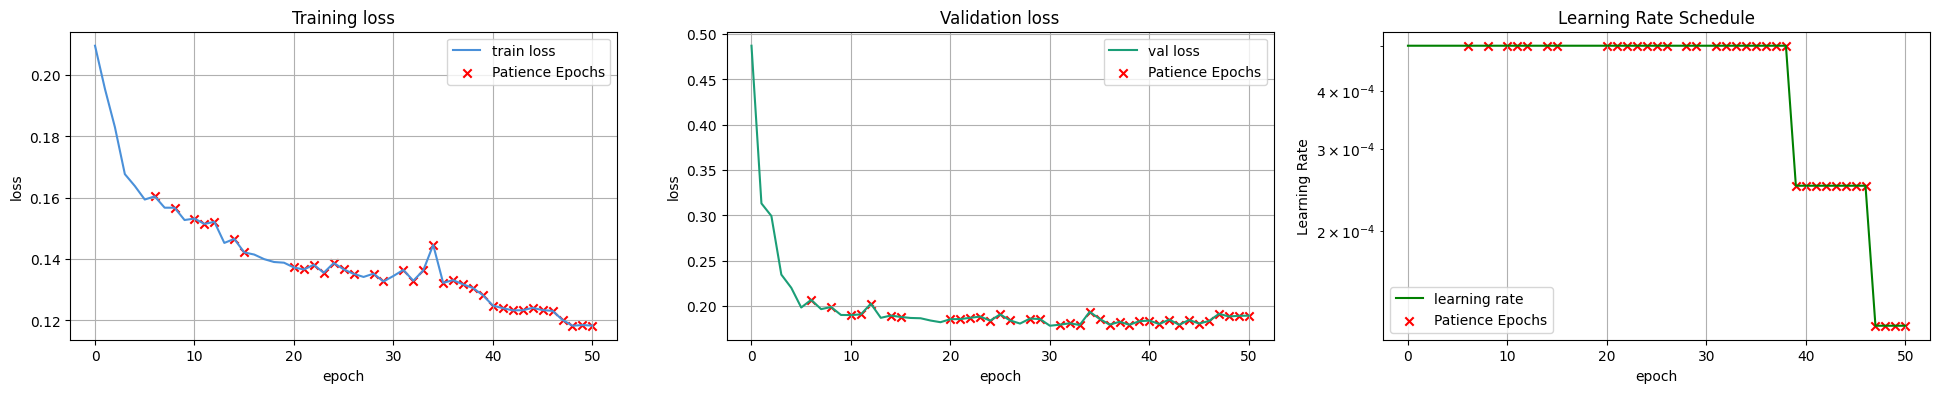

In [34]:
modelname   = 'temporal_gcn__'
gg          = 'commuter_t1000_selfmean_rowwise'
name        = modelname + f"{gg}"

disease_name    = 'influenza'
model           = 'tgcn'
nuts_level      = 'nuts3'
min_date        ='2006-05-15'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False


horizon_size    = 1
horizon_leadtime= 3
sequence_length = 12
lags            = 1


# training hparams
n_epochs        = 100
lr              = 0.0005
min_delta       = 0.0001
loss            = 'smooth_l1'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :   {'mode': 'min', 'factor': 0.5, 'patience': 7},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
}

ml = TGCNModel(dl, name = name)
ml.set_model_hparams()
ml.set_global_hparams(**global_hparams)

ml.train(verbose = 2)
ml.forecast('test')

In [35]:
ml.forecast('train')


Forecasting train: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 641/641 [00:10<00:00, 58.95it/s]


Train loss: 0.1114


(<Figure size 1600x1000 with 2 Axes>,
 array([<Axes: title={'center': 'National aggregation of incidence'}, ylabel='incidence'>,
        <Axes: title={'center': 'predictions node: 69'}, ylabel='incidence'>],
       dtype=object))

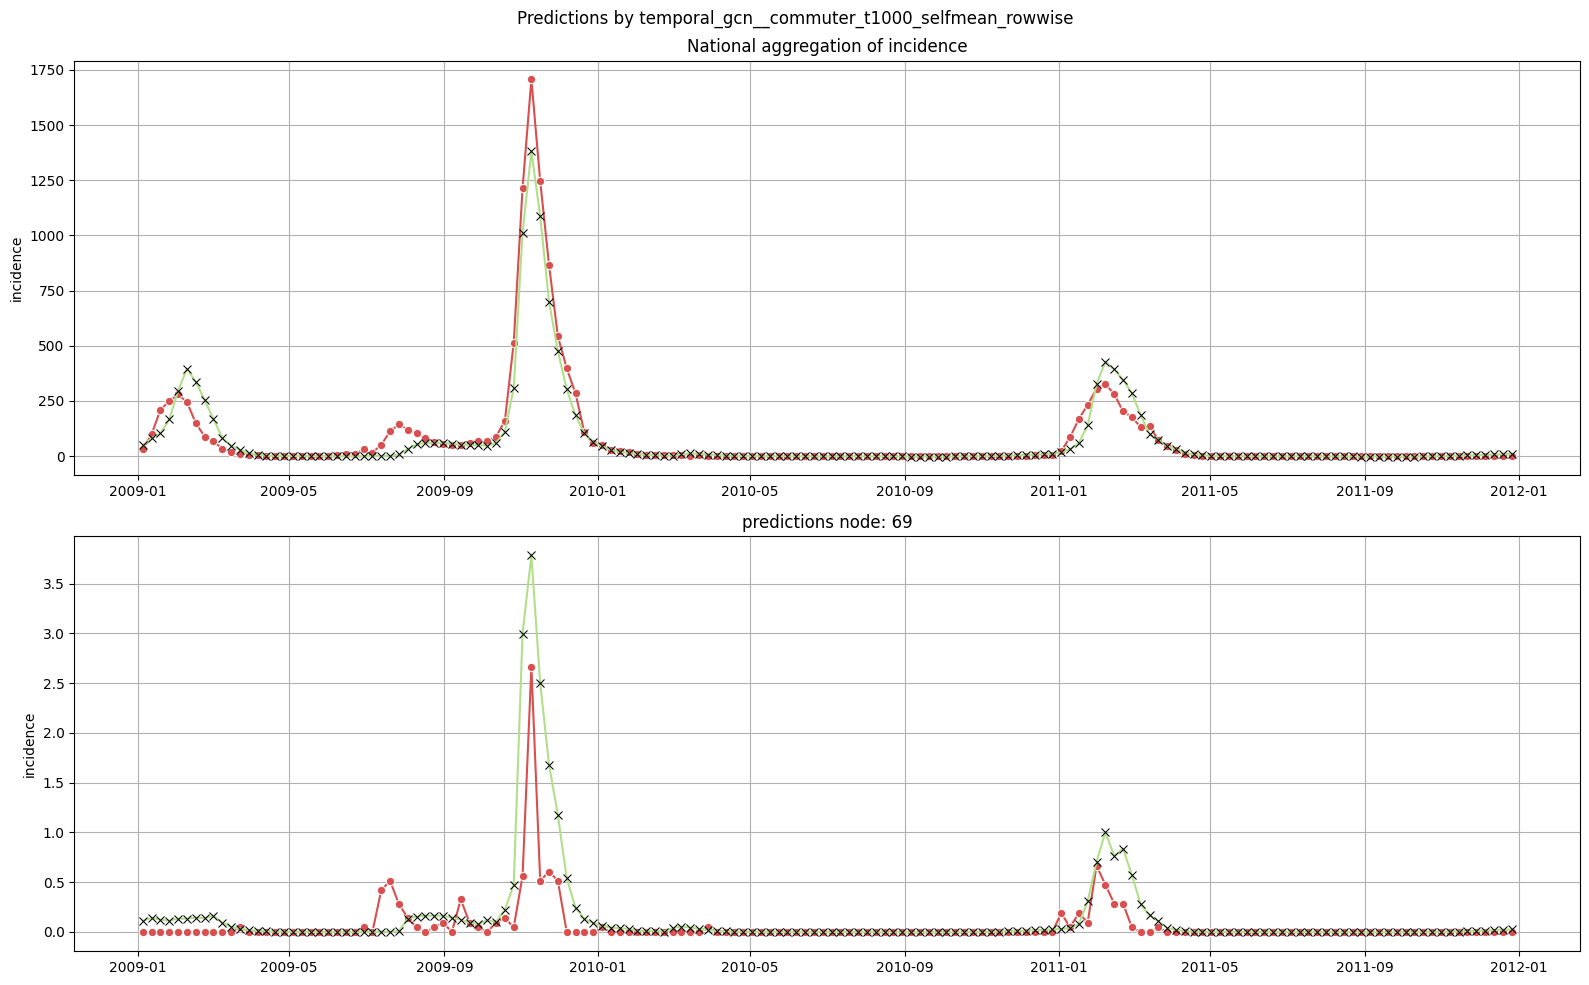

In [33]:
ml.show_forecasts('train', 69, timeframe = ['2009-01-01','2012-01-01'])